# Import all packages

In [1]:
using DifferentialEquations
using OrdinaryDiffEq
using DiffEqBase
using Sundials
using ODEInterfaceDiffEq
using Plots
using Measures
using CSV
using DataFrames
# using Turing
# using MCMCChains
using EasyFit
using StatsPlots
using LinearAlgebra
using Random
using Distributions
using OrdinaryDiffEq
Random.seed!(145975);
using CmdStan
using KernelDensity
using LaTeXStrings
using StatsBase
using JLD2
using BlackBoxOptim
using BlackBoxOptim: num_func_evals
using HypothesisTests
using BayesianOptimization, GaussianProcesses

set_cmdstan_home!("C:\\cmdstan\\cmdstan-2.30.0");

┌ Warning: Environment variable CMDSTAN_HOME not set. Use set_cmdstan_home!.
└ @ CmdStan C:\Users\dgomez\.julia\packages\CmdStan\2vwWj\src\CmdStan.jl:27


In [2]:
include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\BayesianInference\\FunctionsBayesInfs.jl")
include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\InitalParameterFitPriorDef\\ModelFunctionsAll.jl")
include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ComputationalBayesianOED\\FunctionsBayesOED.jl")

redSamples (generic function with 2 methods)

# Define True Theta and Bounds

In [3]:
trueP = [48.0, 55.0,0.005911,0.01832,0.042171,0.5365,0.98047,0.991257,0.93335,0.008241,0.9943848,0.001974,   15];

bounds = [[48, 55, 0.001, 0.005, 0.01, 0.1, 0.7, 0.7, 0.7, 0.005, 0.7, 0.0008, 15],
          [48, 55, 0.01, 0.05, 0.08, 0.8, 1.2, 1.2, 1.2, 0.012, 1.2, 0.005, 15]];


InitsY0 = [450, 12599, 226];

boundY0 = [[300, 7000, 100],
           [1000, 25000, 1000]];

# Generate Pseudodata

In [4]:
dat32mM = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ProcessedData\\4Mil_Dat.csv", DataFrame));

tsC2 = dat32mM[:,1]
ts = 0:tsC2[end];

samps = convert.(Int, tsC2);

## Define Experimental Details

In [5]:
Nexp = 1;

PyrCons = [3.2].*1000

1-element Vector{Float64}:
 3200.0

In [6]:
tsC2 = dat32mM[:,1]
ts = 0:tsC2[end];

ivssAll = Array{Any}(undef, Nexp);
for i in 1:Nexp
    ivssAll[i] = [PyrCons[i], 0, 0, InitsY0[1], InitsY0[2], InitsY0[3], 0, 0, 0, 0, 0, PyrCons[i], 0, PyrCons[i]*(trueP[end]*0.12)];;
end
samps = convert.(Int, tsC2);


1.3

## Simulate Experiments and Extract Observables

In [7]:
SimulsAll = Array{Any}(undef, Nexp,3);
for i in 1:Nexp
    SimulsAll[i,1], SimulsAll[i,2], SimulsAll[i,3]  = PyruvateHP_NMR_SolveAllCp(ts, vcat(trueP, 0), ivssAll[i], samps);
end

In [8]:
ObsS = Array{Any}(undef, Nexp,2);
for i in 1:Nexp
    ObsS[i,1] = SimulsAll[i,1][:,14,1]; # Pyruvate HP
    ObsS[i,2] = SimulsAll[i,1][:,13,1]; # Lactate HP
end


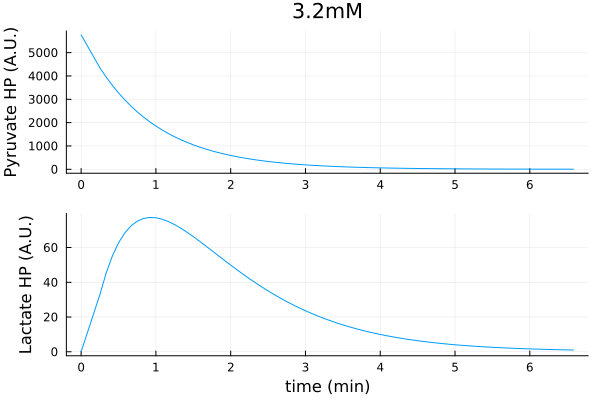

In [9]:
pp1 = plot(samps./60, ObsS[1,1], label = "", title = string(PyrCons[1]/1000)*"mM", ylabel = "Pyruvate HP (A.U.)")
pp2 = plot(samps./60, ObsS[1,2], label = "", ylabel = "Lactate HP (A.U.)", xlabel = "time (min)")

PP1 = plot(pp1,pp2, layout = (2,1))


## Simulate Noise

In [10]:
scf = collect(0.1:0.4:4)
sigm1=0.12; # 10% additive heteroscedastic noise
sigm2=0.075 .*scf;


Random.seed!(45659211); 

SolN1NoiseHet = zeros(length(samps),length(scf),2);
basemat = zeros(length(samps),length(scf),2);

i = 1

for i in 1:length(scf)
    basemat[:,i,1] = ObsS[1,1]'.*sigm1; # introduce new diagonal matrices
    basemat[:,i,2] = ObsS[1,2]'.*sigm2[i];

    for zer in collect(1:length(samps)) # To avoid having standard deviations of 0
        if basemat[zer,i,1]<=1
            basemat[zer,i,1] = 1;
        end
        if basemat[zer,i,2]<=1
            basemat[zer,i,2] = 1;
        end
    end

    SolN1NoiseHet[:,i, 1] = ObsS[1,1]#+rand(MvNormal(zeros(length(samps)),basemat[:,i,1]));
    SolN1NoiseHet[:,i, 2] = ObsS[1,2]+rand(MvNormal(zeros(length(samps)),basemat[:,i,2]));
    SolN1NoiseHet[1,i, 2] = 0;
end

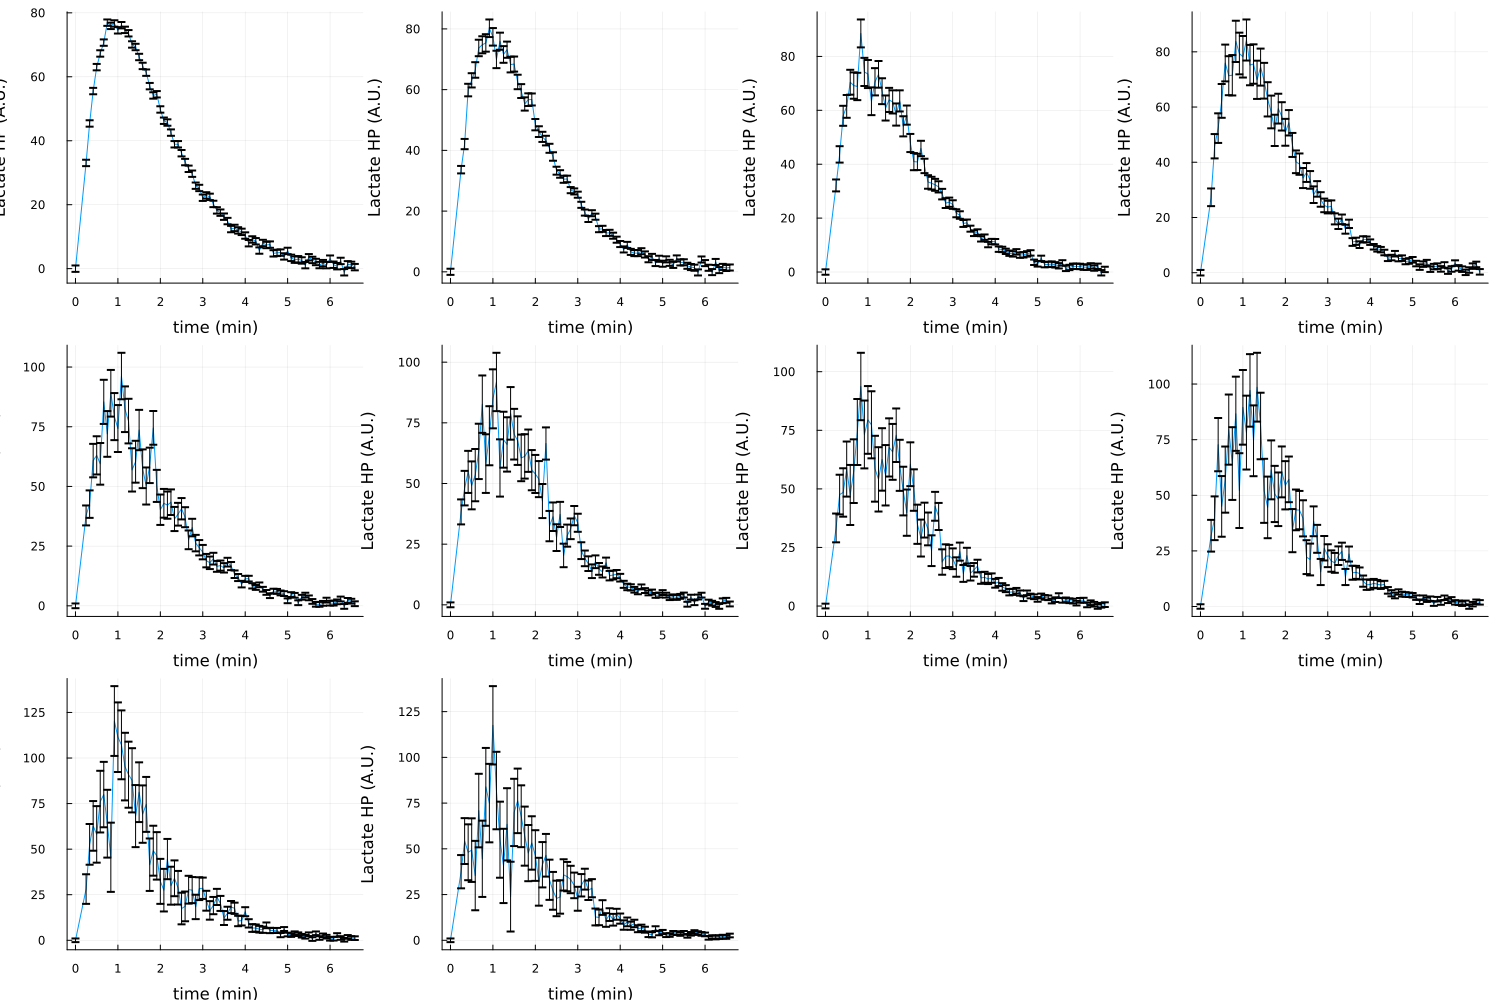

In [11]:
ptss = Array{Any}(undef, length(scf))
for i in 1:length(scf)
    pp1 = plot(samps./60, SolN1NoiseHet[:,i, 1], yerror = basemat[:,i,1], label = "", title = string(PyrCons[1]/1000)*"mM", ylabel = "Pyruvate HP (A.U.)")
    pp2 = plot(samps./60, SolN1NoiseHet[:,i, 2], yerror = basemat[:,i,2], label = "", ylabel = "Lactate HP (A.U.)", xlabel = "time (min)")

    ptss[i] = plot(samps./60, SolN1NoiseHet[:,i, 2], yerror = basemat[:,i,2], label = "", ylabel = "Lactate HP (A.U.)", xlabel = "time (min)")
end



plot(ptss..., size = (1500,1000))

## Generate CSV Files For PseudoData

In [12]:
# Observables
for i in 1:length(scf)
    Observables = zeros(length(samps),5);
    Observables[:,1] = samps;
    Observables[:,2] = SolN1NoiseHet[:,i, 1];
    Observables[:,3] = basemat[:,i, 1];
    Observables[:,4] = SolN1NoiseHet[:,i, 2];
    Observables[:,5] = basemat[:,i, 2];
    obs_head = ["time","Pyr_MEAN","Pyr_STD","Lac_MEAN","Lac_STD"];

    df1 = DataFrame(Observables, :auto);
    rename!(df1, [obs_head[i] for i in 1:5]);
    CSV.write(string("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\PseudoData\\NoiseInfoAnal_STD",sigm2[i],"_Observables_Pyr",string(string(PyrCons[1]/1000)),"mM.csv"), df1);
end

# Bayesian Inference 1

## Extract Data

In [13]:
i = 1;

mainpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\PseudoData\\";

paths = [mainpath*"NoiseInfoAnal_STD"*string(sigm2[i])*"_Observables_Pyr"*string(string(PyrCons[1]/1000))*"mM.csv"]

Random.seed!(231549);
global dat = restructDatInfCompRep_FixedSF(paths, rand(Uniform(boundY0[1][1],boundY0[2][1])), rand(Uniform(boundY0[1][2],boundY0[2][2])), rand(Uniform(boundY0[1][3],boundY0[2][3])), 15)

Dict{String, Any} with 14 entries:
  "Means"  => [5760.0; 4351.83; … ; 3.15287; 2.84159;;; 0.0; 33.0554; … ; 1.187…
  "stsl"   => [78;;]
  "obSta"  => [1 2]
  "sts"    => [0; 15; … ; 390; 395;;]
  "obser"  => 2
  "Y0us"   => [3200.0; 0.0; … ; 0.0; 5760.0;;]
  "ts"     => [1.0e-20; 1.0; … ; 394.0; 395.0;;]
  "itp"    => [0.0]
  "ncells" => [0;;]
  "stslm"  => 78
  "tml"    => 396
  "Erros"  => [691.2; 522.22; … ; 1.0; 1.0;;; 1.0; 1.0; … ; 1.0; 1.0]
  "m"      => 1
  "nts"    => [395;;]

In [14]:
ppT = [48.0, 55.0,0.005911,0.01832,0.042171,0.5365,0.98047,0.991257,0.93335,0.008241,0.9943848,0.001974,   15, 450, 12599, 226]

16-element Vector{Float64}:
    48.0
    55.0
     0.005911
     0.01832
     0.042171
     0.5365
     0.98047
     0.991257
     0.93335
     0.008241
     0.9943848
     0.001974
    15.0
   450.0
 12599.0
   226.0

## Compute structure for Stan's initial guess

In [15]:
function genStanInitDict(samps, names, chains)
    alltog = Array{Dict{String,Any},1}(undef,chains);
    for i in 1:(chains)
        global tmp = Dict{String, Any}()
        for j in 1:length(names)
            tmp[names[j]] = samps[j,i];
        end
        alltog[i] = tmp
    end

    return(alltog)
end

genStanInitDict (generic function with 1 method)

In [135]:
preTrans = zeros(13);

preTrans[1] = (ppT[3]-0.00475)/0.001; 
preTrans[2] = (ppT[4]-0.01375)/0.005;          
preTrans[3] = (ppT[5]-0.045)/0.0025;
preTrans[4] = (ppT[6]-0.55)/0.025;
preTrans[5] = (ppT[7]-0.95)/0.02;
preTrans[6] = (ppT[8]-0.95)/0.02;
preTrans[7] = (ppT[9]-0.95)/0.02;
preTrans[8] = (ppT[10]-0.0085)/0.00025;
preTrans[9] = (ppT[11]-0.95)/0.03;
preTrans[10] = (ppT[12]-0.0020)/0.00015;


preTrans[11] = (ppT[14]-650)/260;
preTrans[12] = (ppT[15]-16000)/6400;
preTrans[13] = (ppT[16]-550)/275;


samps = hcat(preTrans,preTrans,preTrans,preTrans);
names = ["kin","kpl","kbn","kun","kbp","kup","kunE","kbnE","ki","kr","NADH","NAD","LDH"];

ini = genStanInitDict(samps, names, 4);

## Inference

In [ ]:
modelpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\HP_PyrLac_CompetitiveRepressionModel_NoiseInf.stan";
stream = open(modelpath,"r");
Model = read(stream,String);
close(stream);

StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =4,
            num_samples  = 2000, num_warmup = 500, printsummary=true);
StanModel.method.save_warmup = true;
StanModel.method.adapt.delta = 0.85;
StanModel.method.algorithm.stepsize = 0.1;
StanModel.method.algorithm.engine.max_depth=10;
StanModel.method.algorithm.stepsize_jitter = 0.5;

In [ ]:
rc, chns, cnames = stan(StanModel, dat, init = ini) 


Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -4: 
Convergence test failures occurred too many times during one internal time step or minimum step size was reached. (in 'c:/IBECPostDocDrive/2024_01_16_NCvsKR/DataProcessingInference/ComputationalBayesianOED/tmp/PyrCompRepr_ID1_Try1.stan', line 198, column 6 to column 133)
If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.

Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -4: 
Convergence test failures occurred too many times during one internal t

Inference for Stan model: PyrCompRepr_ID1_Try1_model
4 chains: each with iter=(2000,2000,2000,2000); warmup=(1000,1000,1000,1000); thin=(1,1,1,1); 12000 iterations saved.

Warmup took (94072, 90467, 85413, 101140) seconds, 103 hours total
Sampling took (141615, 174601, 189412, 173521) seconds, 189 hours total

                    Mean     MCSE   StdDev        5%       50%       95%    N_Eff  N_Eff/s    R_hat

lp__            -1.6e+02  4.3e-02  2.3e+00  -1.7e+02  -1.6e+02  -1.6e+02  3.0e+03  4.3e-03  1.0e+00
accept_stat__    8.8e-01  1.6e-02  2.1e-01   3.3e-01   9.7e-01      1.00      167  2.5e-04      1.0
stepsize__       7.9e-03  6.2e-04  2.4e-03   4.2e-03   7.8e-03     0.012       16  2.3e-05      1.1
treedepth__      8.6e+00  2.1e-01  1.4e+00   6.0e+00   9.0e+00        10       47  6.9e-05      1.0
n_leapfrog__     5.5e+02  4.5e+01  2.9e+02   1.3e+02   5.1e+02      1023       41  6.0e-05      1.0
divergent__      6.9e-02  4.0e-03  2.5e-01   0.0e+00   0.0e+00       1.0     3943  5.8e

(0, [-159.889 0.906478 … 19360.4 339.343; -159.889 0.0 … 19360.4 339.343; … ; -161.881 0.972239 … 12570.5 235.54; -160.01 0.982909 … 21483.0 192.482;;; -158.525 0.974559 … 17882.4 243.026; -158.525 0.0 … 17882.4 243.026; … ; -160.948 0.998782 … 21275.7 112.211; -158.776 0.742942 … 21304.6 117.698;;; -159.473 0.971854 … 10111.5 511.512; -159.473 0.0 … 10111.5 511.512; … ; -162.186 0.999632 … 25885.1 149.553; -162.903 0.999922 … 13077.0 197.702;;; -158.123 0.989948 … 19812.7 279.898; -158.123 0.0 … 19812.7 279.898; … ; -160.012 0.995577 … 19121.3 110.963; -159.568 0.995477 … 17314.7 334.793], ["lp__", "accept_stat__", "stepsize__", "treedepth__", "n_leapfrog__", "divergent__", "energy__", "kin", "kpl", "kbn"  …  "theta.7", "theta.8", "theta.9", "theta.10", "theta.11", "theta.12", "theta.13", "inits.1", "inits.2", "inits.3"])

"C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_1_Try1.csv"

In [ ]:
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\NoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "rc", rc, "chns", chns, "cnames", cnames)

poster = vcat(chns[1001:end, end-15:end, 1], chns[1001:end, end-15:end, 2], chns[1001:end, end-15:end, 3], chns[1001:end, end-15:end, 4])
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "poster", poster)
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame(poster, :auto))

poster1 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame))

In [20]:
-log(det(cov(hcat(poster[:,3:12], poster[:,14:end]))))

84.46236911473065

# Bayesian Inference 2

## Extract Data

In [21]:
i = 2;

mainpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\PseudoData\\";

paths = [mainpath*"NoiseInfoAnal_STD"*string(sigm2[i])*"_Observables_Pyr"*string(string(PyrCons[1]/1000))*"mM.csv"]

Random.seed!(231549);
global dat = restructDatInfCompRep_FixedSF(paths, rand(Uniform(boundY0[1][1],boundY0[2][1])), rand(Uniform(boundY0[1][2],boundY0[2][2])), rand(Uniform(boundY0[1][3],boundY0[2][3])), 15)

Dict{String, Any} with 14 entries:
  "Means"  => [5760.0; 4351.83; … ; 3.15287; 2.84159;;; 0.0; 33.648; … ; 1.2628…
  "stsl"   => [78;;]
  "obSta"  => [1 2]
  "sts"    => [0; 15; … ; 390; 395;;]
  "obser"  => 2
  "Y0us"   => [3200.0; 0.0; … ; 0.0; 5760.0;;]
  "ts"     => [1.0e-20; 1.0; … ; 394.0; 395.0;;]
  "itp"    => [0.0]
  "ncells" => [0;;]
  "stslm"  => 78
  "tml"    => 396
  "Erros"  => [691.2; 522.22; … ; 1.0; 1.0;;; 1.0; 1.22885; … ; 1.0; 1.0]
  "m"      => 1
  "nts"    => [395;;]

## Compute structure for Stan's initial guess

In [17]:
preTrans = zeros(13);

preTrans[1] = (ppT[3]-0.00475)/0.001; 
preTrans[2] = (ppT[4]-0.01375)/0.005;          
preTrans[3] = (ppT[5]-0.045)/0.0025;
preTrans[4] = (ppT[6]-0.55)/0.025;
preTrans[5] = (ppT[7]-0.95)/0.02;
preTrans[6] = (ppT[8]-0.95)/0.02;
preTrans[7] = (ppT[9]-0.95)/0.02;
preTrans[8] = (ppT[10]-0.0085)/0.00025;
preTrans[9] = (ppT[11]-0.95)/0.03;
preTrans[10] = (ppT[12]-0.0020)/0.00015;


preTrans[11] = (ppT[14]-650)/260;
preTrans[12] = (ppT[15]-16000)/6400;
preTrans[13] = (ppT[16]-550)/275;


samps = hcat(preTrans,preTrans,preTrans,preTrans);
names = ["kin","kpl","kbn","kun","kbp","kup","kunE","kbnE","ki","kr","NADH","NAD","LDH"];

ini = genStanInitDict(samps, names, 4);

## Inference

In [19]:
modelpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\HP_PyrLac_CompetitiveRepressionModel_NoiseInf.stan";
stream = open(modelpath,"r");
Model = read(stream,String);
close(stream);

StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =10,
            num_samples  = 800, num_warmup = 600, printsummary=true);
            
StanModel.method.save_warmup = true;
StanModel.method.adapt.delta = 0.85;
StanModel.method.algorithm.stepsize = 0.1;
StanModel.method.algorithm.engine.max_depth=10;
StanModel.method.algorithm.stepsize_jitter = 0.5;

In [20]:
rc, chns, cnames = stan(StanModel, dat, init = ini) 


Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -4: 
Convergence test failures occurred too many times during one internal time step or minimum step size was reached. (in 'c:/IBECPostDocDrive/2024_01_16_NCvsKR/DataProcessingInference/ExperimentalBayesianOED_OTHERS/tmp/PyrCompRepr_NIC_2_Try1.stan', line 198, column 6 to column 133)
If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.



Inference for Stan model: PyrCompRepr_NIC_2_Try1_model
10 chains: each with iter=(800,800,800,800,800,800,800,800,800,800); warmup=(600,600,600,600,600,600,600,600,600,600); thin=(1,1,1,1,1,1,1,1,1,1); 14000 iterations saved.

Warmup took (32840, 32467, 32406, 31794, 31522, 31981, 35696, 32957, 34035, 34627) seconds, 92 hours total
Sampling took (37302, 36098, 27719, 35618, 38723, 35808, 30207, 33491, 31180, 32806) seconds, 94 hours total

                    Mean     MCSE   StdDev        5%       50%       95%    N_Eff  N_Eff/s    R_hat

lp__            -1.4e+02  4.2e-02  2.5e+00  -1.5e+02  -1.4e+02  -1.4e+02  3.6e+03  1.1e-02  1.0e+00
accept_stat__       0.94  1.9e-03  1.2e-01   7.4e-01      0.98      1.00     3993  1.2e-02      1.0
stepsize__         0.014  7.7e-04  4.4e-03   7.4e-03     0.014     0.022       34  9.9e-05      1.1
treedepth__          8.0  6.7e-02  8.1e-01   7.0e+00       8.0       9.0      147  4.3e-04      1.0
n_leapfrog__         321  1.5e+01  1.4e+02   1.3e+02   

(0, [-142.467 0.859035 … 14510.3 205.332; -142.467 0.0 … 14510.3 205.332; … ; -145.982 0.839124 … 19130.4 308.055; -145.169 0.83185 … 11293.9 180.121;;; -149.333 0.685577 … 29487.1 320.113; -149.333 0.0 … 29487.1 320.113; … ; -145.142 0.979048 … 20491.8 213.295; -145.989 0.815876 … 17287.5 167.866;;; -142.174 0.998394 … 19806.6 233.869; -142.174 0.0 … 19806.6 233.869; … ; -143.962 0.82843 … 9794.96 133.032; -145.712 0.999971 … 10833.4 136.197;;; -145.421 0.59295 … 12717.5 211.91; -145.421 0.0 … 12717.5 211.91; … ; -149.292 0.997751 … 27157.4 176.316; -149.541 0.999792 … 22761.5 168.198;;; -142.054 0.981557 … 14757.2 235.841; -142.054 0.0 … 14757.2 235.841; … ; -144.806 0.99351 … 20037.5 184.813; -144.311 0.980311 … 22335.3 184.691;;; -140.925 0.99101 … 14360.4 204.773; -140.925 0.0 … 14360.4 204.773; … ; -141.397 0.993726 … 13135.7 221.696; -146.163 0.976056 … 10042.1 225.924;;; -143.753 0.949387 … 7823.16 179.447; -143.753 0.0 … 7823.16 179.447; … ; -144.783 0.715874 … 6239.25 134.488

In [21]:
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\NoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "rc", rc, "chns", chns, "cnames", cnames)

poster = vcat(chns[1001:end, end-15:end, 1], chns[1001:end, end-15:end, 2], chns[1001:end, end-15:end, 3], chns[1001:end, end-15:end, 4])
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "poster", poster)
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame(poster, :auto))

poster2 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame))

1600×16 Matrix{Float64}:
 48.0  55.0  0.00544572  0.0188123  …  15.0   396.065  11065.3  230.782
 48.0  55.0  0.00619816  0.0190286     15.0   767.974  20921.3  183.037
 48.0  55.0  0.00542934  0.0190716     15.0   575.597  17779.1  210.867
 48.0  55.0  0.00596342  0.0192404     15.0   830.89   23907.8  178.452
 48.0  55.0  0.00493144  0.019013      15.0   797.679  12656.6  159.077
 48.0  55.0  0.00540395  0.0191176  …  15.0   621.715  15359.9  174.209
 48.0  55.0  0.00485307  0.0198159     15.0   960.129  12569.1  135.405
 48.0  55.0  0.00450238  0.0197878     15.0  1021.2    17041.4  138.823
 48.0  55.0  0.00472316  0.019314      15.0   890.665   5878.1  132.877
 48.0  55.0  0.00537901  0.0191791     15.0   582.689  17503.8  193.864
  ⋮                                 ⋱                             ⋮
 48.0  55.0  0.0060323   0.0188442     15.0   327.026  13044.0  290.796
 48.0  55.0  0.00753052  0.0186777     15.0   555.962  22725.0  237.128
 48.0  55.0  0.00593111  0.018704      15.0

In [22]:
-log(det(cov(hcat(poster[:,3:12], poster[:,14:end]))))

82.6144169612422

# Bayesian Inference 3

## Extract Data

In [15]:
i = 3;

mainpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\PseudoData\\";

paths = [mainpath*"NoiseInfoAnal_STD"*string(sigm2[i])*"_Observables_Pyr"*string(string(PyrCons[1]/1000))*"mM.csv"]

Random.seed!(231549);
global dat = restructDatInfCompRep_FixedSF(paths, rand(Uniform(boundY0[1][1],boundY0[2][1])), rand(Uniform(boundY0[1][2],boundY0[2][2])), rand(Uniform(boundY0[1][3],boundY0[2][3])), 15)

Dict{String, Any} with 14 entries:
  "Means"  => [5760.0; 4351.83; … ; 3.15287; 2.84159;;; 0.0; 32.1331; … ; -0.27…
  "stsl"   => [78;;]
  "obSta"  => [1 2]
  "sts"    => [0; 15; … ; 390; 395;;]
  "obser"  => 2
  "Y0us"   => [3200.0; 0.0; … ; 0.0; 5760.0;;]
  "ts"     => [1.0e-20; 1.0; … ; 394.0; 395.0;;]
  "itp"    => [0.0]
  "ncells" => [0;;]
  "stslm"  => 78
  "tml"    => 396
  "Erros"  => [691.2; 522.22; … ; 1.0; 1.0;;; 1.0; 2.21192; … ; 1.0; 1.0]
  "m"      => 1
  "nts"    => [395;;]

## Compute structure for Stan's initial guess

In [16]:
preTrans = zeros(13);

preTrans[1] = (ppT[3]-0.00475)/0.001; 
preTrans[2] = (ppT[4]-0.01375)/0.005;          
preTrans[3] = (ppT[5]-0.045)/0.0025;
preTrans[4] = (ppT[6]-0.55)/0.025;
preTrans[5] = (ppT[7]-0.95)/0.02;
preTrans[6] = (ppT[8]-0.95)/0.02;
preTrans[7] = (ppT[9]-0.95)/0.02;
preTrans[8] = (ppT[10]-0.0085)/0.00025;
preTrans[9] = (ppT[11]-0.95)/0.03;
preTrans[10] = (ppT[12]-0.0020)/0.00015;


preTrans[11] = (ppT[14]-650)/260;
preTrans[12] = (ppT[15]-16000)/6400;
preTrans[13] = (ppT[16]-550)/275;


samps = hcat(preTrans,preTrans,preTrans,preTrans);
names = ["kin","kpl","kbn","kun","kbp","kup","kunE","kbnE","ki","kr","NADH","NAD","LDH"];

ini = genStanInitDict(samps, names, 4);

## Inference

In [17]:
modelpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\HP_PyrLac_CompetitiveRepressionModel_NoiseInf.stan";
stream = open(modelpath,"r");
Model = read(stream,String);
close(stream);

StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =10,
            num_samples  = 800, num_warmup = 600, printsummary=true);
StanModel.method.save_warmup = true;
StanModel.method.adapt.delta = 0.85;
StanModel.method.algorithm.stepsize = 0.1;
StanModel.method.algorithm.engine.max_depth=10;
StanModel.method.algorithm.stepsize_jitter = 0.5;

In [18]:
rc, chns, cnames = stan(StanModel, dat, init = ini) 


Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -4: 
Convergence test failures occurred too many times during one internal time step or minimum step size was reached. (in 'c:/IBECPostDocDrive/2024_01_16_NCvsKR/DataProcessingInference/ExperimentalBayesianOED_OTHERS/tmp/PyrCompRepr_NIC_3_Try1.stan', line 198, column 6 to column 133)
If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.

Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -1: 
The solver took mxstep internal steps but could not reach tout.

Inference for Stan model: PyrCompRepr_NIC_3_Try1_model
10 chains: each with iter=(800,800,800,800,800,800,800,800,800,800); warmup=(600,600,600,600,600,600,600,600,600,600); thin=(1,1,1,1,1,1,1,1,1,1); 14000 iterations saved.

Warmup took (19919, 20952, 22892, 21364, 19600, 21129, 22322, 23205, 20361, 20415) seconds, 59 hours total
Sampling took (20597, 17047, 18607, 20460, 17670, 17095, 16426, 17348, 14802, 19485) seconds, 50 hours total

                    Mean     MCSE   StdDev        5%       50%       95%    N_Eff  N_Eff/s    R_hat

lp__            -1.5e+02  4.2e-02  2.5e+00  -1.6e+02  -1.5e+02  -1.5e+02  3.4e+03  1.9e-02  1.0e+00
accept_stat__       0.94  2.4e-03  1.2e-01      0.73      0.98      1.00     2653  1.5e-02      1.0
stepsize__         0.025  1.5e-03  8.0e-03     0.013     0.024     0.039       30  1.7e-04      1.1
treedepth__          7.2  6.7e-02  7.8e-01       6.0       7.0       8.0      136  7.6e-04      1.0
n_leapfrog__         185  8.3e+00  8.5e+01        98   

(0, [-155.648 0.554117 … 12296.4 234.396; -155.648 0.0 … 12296.4 234.396; … ; -157.644 0.985835 … 1831.16 132.107; -156.987 0.996851 … 3825.24 135.637;;; -157.337 0.804437 … 13605.2 268.589; -157.337 0.0 … 13605.2 268.589; … ; -155.894 0.972714 … 12103.8 209.499; -153.692 0.998886 … 21257.3 214.134;;; -155.226 0.820984 … 14687.8 241.133; -155.226 0.0 … 14687.8 241.133; … ; -151.644 0.999985 … 12986.0 143.341; -151.122 0.994636 … 12708.4 160.172;;; -156.66 0.000104966 … 12599.0 226.0; -156.66 0.0 … 12599.0 226.0; … ; -152.959 0.989351 … 11199.5 154.89; -154.753 0.906492 … 14000.2 147.156;;; -159.877 0.790769 … 15518.5 234.169; -159.877 0.0 … 15518.5 234.169; … ; -156.782 0.999203 … 30801.5 175.959; -155.741 0.92287 … 5978.76 160.501;;; -151.392 0.747315 … 14458.7 206.358; -151.392 0.0 … 14458.7 206.358; … ; -153.643 0.999246 … 20572.1 205.63; -154.697 0.564512 … 10323.3 141.89;;; -151.017 0.985066 … 12515.7 157.362; -151.017 0.0 … 12515.7 157.362; … ; -152.679 0.951403 … 15813.0 149.009

In [19]:
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\NoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "rc", rc, "chns", chns, "cnames", cnames)

poster = vcat(chns[1001:end, end-15:end, 1], chns[1001:end, end-15:end, 2], chns[1001:end, end-15:end, 3], chns[1001:end, end-15:end, 4])
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "poster", poster)
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame(poster, :auto))

poster3 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame))

1600×16 Matrix{Float64}:
 48.0  55.0  0.00610423  0.0188725  …  15.0   344.482  22669.4   299.212
 48.0  55.0  0.0058607   0.0177226     15.0   576.31   11984.4   185.306
 48.0  55.0  0.00513426  0.0198687     15.0  1071.24   21969.4   149.972
 48.0  55.0  0.00593386  0.0174396     15.0   265.133   1630.74  222.755
 48.0  55.0  0.00566243  0.0186023     15.0   747.457  13586.5   154.931
 48.0  55.0  0.00612939  0.0179498  …  15.0   479.228  18148.8   257.334
 48.0  55.0  0.00499609  0.0189661     15.0   858.207  10523.1   132.559
 48.0  55.0  0.00504527  0.0190695     15.0   840.692  14645.3   147.51
 48.0  55.0  0.00599405  0.0187178     15.0   755.414  26263.8   179.471
 48.0  55.0  0.00507142  0.0182872     15.0   721.731   6683.84  143.073
  ⋮                                 ⋱                              ⋮
 48.0  55.0  0.00535942  0.0183942     15.0  1047.48   15996.6   138.11
 48.0  55.0  0.00602667  0.0178354     15.0   416.918  14974.0   239.856
 48.0  55.0  0.00555321  0.01793

In [21]:
-log(det(cov(hcat(poster[:,3:12], poster[:,14:end]))))

81.74274500410598

# Bayesian Inference 4

## Extract Data

In [18]:
i = 4;

mainpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\PseudoData\\";

paths = [mainpath*"NoiseInfoAnal_STD"*string(sigm2[i])*"_Observables_Pyr"*string(string(PyrCons[1]/1000))*"mM.csv"]

Random.seed!(231549);
global dat = restructDatInfCompRep_FixedSF(paths, rand(Uniform(boundY0[1][1],boundY0[2][1])), rand(Uniform(boundY0[1][2],boundY0[2][2])), rand(Uniform(boundY0[1][3],boundY0[2][3])), 15)

Dict{String, Any} with 14 entries:
  "Means"  => [5760.0; 4351.83; … ; 3.15287; 2.84159;;; 0.0; 27.3123; … ; 2.980…
  "stsl"   => [78;;]
  "obSta"  => [1 2]
  "sts"    => [0; 15; … ; 390; 395;;]
  "obser"  => 2
  "Y0us"   => [3200.0; 0.0; … ; 0.0; 5760.0;;]
  "ts"     => [1.0e-20; 1.0; … ; 394.0; 395.0;;]
  "itp"    => [0.0]
  "ncells" => [0;;]
  "stslm"  => 78
  "tml"    => 396
  "Erros"  => [691.2; 522.22; … ; 1.0; 1.0;;; 1.0; 3.195; … ; 1.0; 1.0]
  "m"      => 1
  "nts"    => [395;;]

## Compute structure for Stan's initial guess

In [17]:
preTrans = zeros(13);

preTrans[1] = (ppT[3]-0.00475)/0.001; 
preTrans[2] = (ppT[4]-0.01375)/0.005;          
preTrans[3] = (ppT[5]-0.045)/0.0025;
preTrans[4] = (ppT[6]-0.55)/0.025;
preTrans[5] = (ppT[7]-0.95)/0.02;
preTrans[6] = (ppT[8]-0.95)/0.02;
preTrans[7] = (ppT[9]-0.95)/0.02;
preTrans[8] = (ppT[10]-0.0085)/0.00025;
preTrans[9] = (ppT[11]-0.95)/0.03;
preTrans[10] = (ppT[12]-0.0020)/0.00015;


preTrans[11] = (ppT[14]-650)/260;
preTrans[12] = (ppT[15]-16000)/6400;
preTrans[13] = (ppT[16]-550)/275;


samps = hcat(preTrans,preTrans,preTrans,preTrans);
names = ["kin","kpl","kbn","kun","kbp","kup","kunE","kbnE","ki","kr","NADH","NAD","LDH"];

ini = genStanInitDict(samps, names, 4);

## Inference

In [20]:
modelpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\HP_PyrLac_CompetitiveRepressionModel_NoiseInf.stan";
stream = open(modelpath,"r");
Model = read(stream,String);
close(stream);

# StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =4,
#             num_samples  = 2000, num_warmup = 1000, printsummary=true);
StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =10,
            num_samples  = 800, num_warmup = 600, printsummary=true);
StanModel.method.save_warmup = true;
StanModel.method.adapt.delta = 0.85;
StanModel.method.algorithm.stepsize = 0.1;
StanModel.method.algorithm.engine.max_depth=10;
StanModel.method.algorithm.stepsize_jitter = 0.5;

In [21]:
rc, chns, cnames = stan(StanModel, dat, init = ini) 


Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -4: 
Convergence test failures occurred too many times during one internal time step or minimum step size was reached. (in 'c:/IBECPostDocDrive/2024_01_16_NCvsKR/DataProcessingInference/ExperimentalBayesianOED_OTHERS/tmp/PyrCompRepr_NIC_4_Try1.stan', line 198, column 6 to column 133)
If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.

Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -1: 
The solver took mxstep internal steps but could not reach tout.

Inference for Stan model: PyrCompRepr_NIC_4_Try1_model
10 chains: each with iter=(800,800,800,800,800,800,800,800,800,800); warmup=(600,600,600,600,600,600,600,600,600,600); thin=(1,1,1,1,1,1,1,1,1,1); 14000 iterations saved.

Warmup took (25703, 27933, 25555, 24215, 23296, 23547, 23791, 22564, 23446, 22876) seconds, 67 hours total
Sampling took (23905, 30892, 27140, 28678, 25487, 21553, 27472, 28033, 25944, 23398) seconds, 73 hours total

                    Mean     MCSE   StdDev        5%       50%       95%    N_Eff  N_Eff/s    R_hat

lp__            -1.7e+02  4.2e-02  2.5e+00  -1.7e+02  -1.7e+02  -1.6e+02  3.5e+03  1.3e-02  1.0e+00
accept_stat__    9.5e-01  3.4e-03  1.0e-01   7.5e-01      0.98      1.00      906  3.5e-03  1.0e+00
stepsize__       1.8e-02  1.1e-03  5.8e-03   9.5e-03     0.018     0.028       28  1.1e-04  1.1e+00
treedepth__      7.7e+00  9.1e-02  6.8e-01   7.0e+00       8.0       9.0       55  2.1e-04  1.1e+00
n_leapfrog__     2.5e+02  1.6e+01  1.2e+02   1.3e+02   

(0, [-168.122 0.983932 … 18279.3 142.142; -168.122 0.0 … 18279.3 142.142; … ; -164.322 0.970567 … 16691.3 166.629; -165.233 0.999055 … 12327.7 259.261;;; -163.843 0.999104 … 21245.6 204.742; -163.843 0.0 … 21245.6 204.742; … ; -164.611 0.997739 … 21686.1 248.919; -163.211 0.999005 … 14106.4 387.399;;; -165.098 0.986957 … 18117.5 174.49; -165.098 0.0 … 18117.5 174.49; … ; -166.585 0.863695 … 28402.9 212.595; -165.535 0.986319 … 16949.8 167.39;;; -164.495 0.952629 … 20441.2 432.168; -164.495 0.0 … 20441.2 432.168; … ; -162.062 0.969176 … 13884.5 261.794; -167.046 0.992369 … 6598.33 173.64;;; -168.915 0.223216 … 12156.9 222.558; -168.915 0.0 … 12156.9 222.558; … ; -167.103 0.947707 … 16848.0 220.894; -164.966 0.994999 … 17597.9 274.645;;; -166.706 0.656532 … 22718.5 196.399; -166.706 0.0 … 22718.5 196.399; … ; -166.725 0.998686 … 14130.5 171.694; -165.704 0.943327 … 19655.9 142.267;;; -165.403 0.986217 … 26374.7 197.043; -165.403 0.0 … 26374.7 197.043; … ; -166.401 0.891162 … 13969.0 264.

In [22]:
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\NoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "rc", rc, "chns", chns, "cnames", cnames)

poster = vcat(chns[1001:end, end-15:end, 1], chns[1001:end, end-15:end, 2], chns[1001:end, end-15:end, 3], chns[1001:end, end-15:end, 4])
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "poster", poster)
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame(poster, :auto))

poster4 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame))

1600×16 Matrix{Float64}:
 48.0  55.0  0.00423297  0.0199158  …  15.0  672.606  17807.5   162.123
 48.0  55.0  0.00379938  0.0198529     15.0  674.01   15896.3   160.564
 48.0  55.0  0.0043879   0.0195416     15.0  632.501  10388.4   160.507
 48.0  55.0  0.00418691  0.0193177     15.0  377.576  11480.9   233.004
 48.0  55.0  0.00519318  0.0184219     15.0  397.101  13745.6   246.03
 48.0  55.0  0.00324229  0.0205564  …  15.0  832.293  18066.2   148.973
 48.0  55.0  0.00446749  0.0196739     15.0  887.088  15041.0   146.724
 48.0  55.0  0.0041975   0.0188691     15.0  432.583   4520.49  186.557
 48.0  55.0  0.00454256  0.0194779     15.0  595.711  14862.6   182.158
 48.0  55.0  0.00338406  0.0190784     15.0  625.903  10687.3   158.589
  ⋮                                 ⋱                             ⋮
 48.0  55.0  0.00398449  0.0194348     15.0  315.249   9962.23  249.153
 48.0  55.0  0.00691536  0.0183173     15.0  274.075  18266.6   368.676
 48.0  55.0  0.00477032  0.019507      15.0 

In [23]:
-log(det(cov(hcat(poster[:,3:12], poster[:,14:end]))))

78.85921175548681

# Bayesian Inference 5

## Extract Data

In [15]:
i = 5;

mainpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\PseudoData\\";

paths = [mainpath*"NoiseInfoAnal_STD"*string(sigm2[i])*"_Observables_Pyr"*string(string(PyrCons[1]/1000))*"mM.csv"]

Random.seed!(231549);
global dat = restructDatInfCompRep_FixedSF(paths, rand(Uniform(boundY0[1][1],boundY0[2][1])), rand(Uniform(boundY0[1][2],boundY0[2][2])), rand(Uniform(boundY0[1][3],boundY0[2][3])), 15)

Dict{String, Any} with 14 entries:
  "Means"  => [5760.0; 4351.83; … ; 3.15287; 2.84159;;; 0.0; 37.8633; … ; 1.932…
  "stsl"   => [78;;]
  "obSta"  => [1 2]
  "sts"    => [0; 15; … ; 390; 395;;]
  "obser"  => 2
  "Y0us"   => [3200.0; 0.0; … ; 0.0; 5760.0;;]
  "ts"     => [1.0e-20; 1.0; … ; 394.0; 395.0;;]
  "itp"    => [0.0]
  "ncells" => [0;;]
  "stslm"  => 78
  "tml"    => 396
  "Erros"  => [691.2; 522.22; … ; 1.0; 1.0;;; 1.0; 4.17808; … ; 1.0; 1.0]
  "m"      => 1
  "nts"    => [395;;]

## Compute structure for Stan's initial guess

In [16]:
preTrans = zeros(13);

preTrans[1] = (ppT[3]-0.00475)/0.001; 
preTrans[2] = (ppT[4]-0.01375)/0.005;          
preTrans[3] = (ppT[5]-0.045)/0.0025;
preTrans[4] = (ppT[6]-0.55)/0.025;
preTrans[5] = (ppT[7]-0.95)/0.02;
preTrans[6] = (ppT[8]-0.95)/0.02;
preTrans[7] = (ppT[9]-0.95)/0.02;
preTrans[8] = (ppT[10]-0.0085)/0.00025;
preTrans[9] = (ppT[11]-0.95)/0.03;
preTrans[10] = (ppT[12]-0.0020)/0.00015;


preTrans[11] = (ppT[14]-650)/260;
preTrans[12] = (ppT[15]-16000)/6400;
preTrans[13] = (ppT[16]-550)/275;


samps = hcat(preTrans,preTrans,preTrans,preTrans);
names = ["kin","kpl","kbn","kun","kbp","kup","kunE","kbnE","ki","kr","NADH","NAD","LDH"];

ini = genStanInitDict(samps, names, 4);

## Inference

In [18]:
modelpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\HP_PyrLac_CompetitiveRepressionModel_NoiseInf.stan";
stream = open(modelpath,"r");
Model = read(stream,String);
close(stream);

# StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =4,
#             num_samples  = 2000, num_warmup = 1000, printsummary=true);
StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =10,
            num_samples  = 800, num_warmup = 600, printsummary=true);
StanModel.method.save_warmup = true;
StanModel.method.adapt.delta = 0.85;
StanModel.method.algorithm.stepsize = 0.1;
StanModel.method.algorithm.engine.max_depth=10;
StanModel.method.algorithm.stepsize_jitter = 0.5;

In [19]:
rc, chns, cnames = stan(StanModel, dat, init = ini) 


Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -4: 
Convergence test failures occurred too many times during one internal time step or minimum step size was reached. (in 'c:/IBECPostDocDrive/2024_01_16_NCvsKR/DataProcessingInference/ExperimentalBayesianOED_OTHERS/tmp/PyrCompRepr_NIC_5_Try1.stan', line 198, column 6 to column 133)
If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.

Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -4: 
Convergence test failures occurred too many times during one in

Inference for Stan model: PyrCompRepr_NIC_5_Try1_model
10 chains: each with iter=(800,800,800,800,800,800,800,800,800,800); warmup=(600,600,600,600,600,600,600,600,600,600); thin=(1,1,1,1,1,1,1,1,1,1); 14000 iterations saved.

Warmup took (17204, 13629, 16227, 17566, 18112, 16717, 15036, 15747, 16665, 14710) seconds, 45 hours total
Sampling took (11982, 9990, 9282, 11491, 17984, 11519, 12923, 13976, 11949, 17221) seconds, 36 hours total

                    Mean     MCSE   StdDev        5%       50%       95%    N_Eff  N_Eff/s    R_hat

lp__            -1.9e+02  4.4e-02  2.5e+00  -2.0e+02  -1.9e+02  -1.9e+02  3.3e+03  2.6e-02  1.0e+00
accept_stat__       0.93  4.8e-03     0.15      0.65      0.98      1.00      967  7.5e-03      1.0
stepsize__         0.036  3.6e-03    0.013     0.017     0.034     0.059       13  1.0e-04      1.3
treedepth__          6.7  1.7e-01     0.89       6.0       7.0       8.0       28  2.1e-04      1.1
n_leapfrog__         128  1.6e+01       70        63     

(0, [-193.877 0.948526 … 15769.6 158.439; -193.877 0.0 … 15769.6 158.439; … ; -195.241 0.979704 … 13709.7 140.245; -190.833 0.998385 … 12101.5 176.31;;; -196.07 0.936958 … 7994.3 175.907; -196.07 0.0 … 7994.3 175.907; … ; -192.62 0.992413 … 22643.9 228.853; -193.825 0.644606 … 16025.0 188.967;;; -193.699 0.333333 … 12799.1 222.51; -193.699 0.0 … 12799.1 222.51; … ; -191.007 0.941534 … 10978.3 205.706; -189.718 0.998613 … 13785.7 190.497;;; -192.14 0.859533 … 13115.0 255.178; -192.14 0.0 … 13115.0 255.178; … ; -191.434 0.989658 … 16883.9 242.228; -192.863 0.998875 … 7457.1 157.93;;; -194.48 0.903228 … 29406.4 194.02; -194.48 0.0 … 29406.4 194.02; … ; -194.384 0.84367 … 16069.5 200.143; -195.719 0.999738 … 13069.2 166.743;;; -191.979 0.935241 … 12779.2 156.505; -191.979 0.0 … 12779.2 156.505; … ; -194.032 0.843092 … 21915.8 184.747; -195.398 0.982059 … 31949.5 233.482;;; -195.956 0.274092 … 10215.2 260.098; -195.956 0.0 … 10215.2 260.098; … ; -193.795 0.996472 … 20010.3 343.268; -192.614

In [20]:
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\NoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "rc", rc, "chns", chns, "cnames", cnames)

poster = vcat(chns[1001:end, end-15:end, 1], chns[1001:end, end-15:end, 2], chns[1001:end, end-15:end, 3], chns[1001:end, end-15:end, 4])
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "poster", poster)
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame(poster, :auto))

poster5 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame))

1600×16 Matrix{Float64}:
 48.0  55.0  0.0063974   0.0191227  …  15.0  1025.7    12307.7   148.71
 48.0  55.0  0.00486827  0.0189927     15.0   896.738  17641.2   151.86
 48.0  55.0  0.00610811  0.0183771     15.0   678.97    8741.64  170.655
 48.0  55.0  0.00475187  0.0195374     15.0   649.411  20503.7   188.056
 48.0  55.0  0.00565442  0.0194349     15.0   968.77   22132.6   162.02
 48.0  55.0  0.00524814  0.0194419  …  15.0   868.466  16984.1   160.452
 48.0  55.0  0.00516312  0.0195438     15.0   871.199  20396.0   161.899
 48.0  55.0  0.00478932  0.0189938     15.0   576.635   9776.39  173.046
 48.0  55.0  0.00598135  0.0189186     15.0   933.576  18574.3   163.977
 48.0  55.0  0.00493711  0.0190463     15.0   583.973   8322.8   169.503
  ⋮                                 ⋱                              ⋮
 48.0  55.0  0.00693396  0.0191182     15.0   590.999  19462.9   222.202
 48.0  55.0  0.00496585  0.0178444     15.0   394.812  14051.6   233.164
 48.0  55.0  0.00614497  0.018478

In [23]:
-log(det(cov(hcat(poster[:,3:12], poster[:,14:end]))))

79.45933104610721

# Bayesian Inference 6

## Extract Data

In [15]:
i = 6;

mainpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\PseudoData\\";

paths = [mainpath*"NoiseInfoAnal_STD"*string(sigm2[i])*"_Observables_Pyr"*string(string(PyrCons[1]/1000))*"mM.csv"]

Random.seed!(231549);
global dat = restructDatInfCompRep_FixedSF(paths, rand(Uniform(boundY0[1][1],boundY0[2][1])), rand(Uniform(boundY0[1][2],boundY0[2][2])), rand(Uniform(boundY0[1][3],boundY0[2][3])), 15)

Dict{String, Any} with 14 entries:
  "Means"  => [5760.0; 4351.83; … ; 3.15287; 2.84159;;; 0.0; 38.2986; … ; 1.870…
  "stsl"   => [78;;]
  "obSta"  => [1 2]
  "sts"    => [0; 15; … ; 390; 395;;]
  "obser"  => 2
  "Y0us"   => [3200.0; 0.0; … ; 0.0; 5760.0;;]
  "ts"     => [1.0e-20; 1.0; … ; 394.0; 395.0;;]
  "itp"    => [0.0]
  "ncells" => [0;;]
  "stslm"  => 78
  "tml"    => 396
  "Erros"  => [691.2; 522.22; … ; 1.0; 1.0;;; 1.0; 5.16115; … ; 1.0; 1.0]
  "m"      => 1
  "nts"    => [395;;]

## Compute structure for Stan's initial guess

In [16]:
preTrans = zeros(13);

preTrans[1] = (ppT[3]-0.00475)/0.001; 
preTrans[2] = (ppT[4]-0.01375)/0.005;          
preTrans[3] = (ppT[5]-0.045)/0.0025;
preTrans[4] = (ppT[6]-0.55)/0.025;
preTrans[5] = (ppT[7]-0.95)/0.02;
preTrans[6] = (ppT[8]-0.95)/0.02;
preTrans[7] = (ppT[9]-0.95)/0.02;
preTrans[8] = (ppT[10]-0.0085)/0.00025;
preTrans[9] = (ppT[11]-0.95)/0.03;
preTrans[10] = (ppT[12]-0.0020)/0.00015;


preTrans[11] = (ppT[14]-650)/260;
preTrans[12] = (ppT[15]-16000)/6400;
preTrans[13] = (ppT[16]-550)/275;


samps = hcat(preTrans,preTrans,preTrans,preTrans);
names = ["kin","kpl","kbn","kun","kbp","kup","kunE","kbnE","ki","kr","NADH","NAD","LDH"];

ini = genStanInitDict(samps, names, 4);

## Inference

In [18]:
modelpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\HP_PyrLac_CompetitiveRepressionModel_NoiseInf.stan";
stream = open(modelpath,"r");
Model = read(stream,String);
close(stream);

# StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =4,
#             num_samples  = 2000, num_warmup = 1000, printsummary=true);
StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =10,
            num_samples  = 800, num_warmup = 600, printsummary=true);
StanModel.method.save_warmup = true;
StanModel.method.adapt.delta = 0.85;
StanModel.method.algorithm.stepsize = 0.1;
StanModel.method.algorithm.engine.max_depth=10;
StanModel.method.algorithm.stepsize_jitter = 0.5;

In [19]:
rc, chns, cnames = stan(StanModel, dat, init = ini) 


Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -4: 
Convergence test failures occurred too many times during one internal time step or minimum step size was reached. (in 'c:/IBECPostDocDrive/2024_01_16_NCvsKR/DataProcessingInference/ExperimentalBayesianOED_OTHERS/tmp/PyrCompRepr_NIC_6_Try1.stan', line 198, column 6 to column 133)
If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.

Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -4: 
Convergence test failures occurred too many times during one in

Inference for Stan model: PyrCompRepr_NIC_6_Try1_model
10 chains: each with iter=(800,800,800,800,800,800,800,800,800,800); warmup=(600,600,600,600,600,600,600,600,600,600); thin=(1,1,1,1,1,1,1,1,1,1); 14000 iterations saved.

Warmup took (20775, 22692, 18995, 23738, 23329, 22795, 21179, 25958, 27105, 21928) seconds, 63 hours total
Sampling took (19068, 29796, 24703, 24026, 22145, 31702, 20324, 26406, 21701, 26889) seconds, 69 hours total

                    Mean     MCSE   StdDev        5%       50%      95%    N_Eff  N_Eff/s    R_hat

lp__            -2.1e+02  4.5e-02  2.5e+00  -2.2e+02  -2.1e+02 -2.1e+02  3.2e+03  1.3e-02  1.0e+00
accept_stat__       0.93  1.1e-02  1.4e-01   6.5e-01      0.98     1.00      157  6.4e-04      1.0
stepsize__         0.019  1.6e-03  6.5e-03   9.3e-03     0.018    0.030       16  6.7e-05      1.2
treedepth__          7.6  1.4e-01  7.9e-01   7.0e+00       8.0      9.0       32  1.3e-04      1.1
n_leapfrog__         243  2.2e+01  1.2e+02   1.3e+02       2

(0, [-212.184 0.000198507 … 12599.0 226.0; -212.184 0.0 … 12599.0 226.0; … ; -212.846 0.856051 … 22629.8 780.203; -212.57 0.207633 … 22122.4 811.643;;; -208.324 0.978477 … 17651.1 296.815; -208.324 0.0 … 17651.1 296.815; … ; -209.756 0.987376 … 7545.99 178.307; -209.04 0.8271 … 17816.2 174.276;;; -212.184 0.0862337 … 12599.0 226.0; -212.184 0.0 … 12599.0 226.0; … ; -209.674 0.999598 … 12123.6 274.263; -208.447 0.996547 … 19964.7 201.909;;; -210.079 0.996605 … 15059.6 192.591; -210.079 0.0 … 15059.6 192.591; … ; -212.837 0.955357 … 13358.7 196.749; -212.6 0.987765 … 18504.5 198.021;;; -211.112 0.989263 … 12048.7 236.858; -211.112 0.0 … 12048.7 236.858; … ; -209.477 0.599356 … 19607.1 775.047; -213.147 0.959551 … 13478.8 699.992;;; -211.684 0.820139 … 12998.8 574.557; -211.684 0.0 … 12998.8 574.557; … ; -210.057 0.967647 … 13853.4 363.238; -209.649 0.999431 … 18498.6 194.305;;; -212.46 0.632814 … 21920.4 269.218; -212.46 0.0 … 21920.4 269.218; … ; -212.505 0.925348 … 28459.0 241.47; -213

In [20]:
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\NoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "rc", rc, "chns", chns, "cnames", cnames)

poster = vcat(chns[1001:end, end-15:end, 1], chns[1001:end, end-15:end, 2], chns[1001:end, end-15:end, 3], chns[1001:end, end-15:end, 4])
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "poster", poster)
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame(poster, :auto))

poster6 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame))

1600×16 Matrix{Float64}:
 48.0  55.0  0.00457922  0.0191815  …  15.0  471.785  11661.2   208.118
 48.0  55.0  0.00610195  0.0192465     15.0  214.249  24190.0   635.676
 48.0  55.0  0.00511857  0.0181935     15.0  236.927   6946.41  348.825
 48.0  55.0  0.00545274  0.0192589     15.0  250.552  12968.0   379.992
 48.0  55.0  0.00502648  0.0183504     15.0  252.204  18711.4   409.423
 48.0  55.0  0.00522024  0.0182716  …  15.0  255.442  22008.9   405.541
 48.0  55.0  0.00683683  0.0193636     15.0  400.433  22968.1   323.28
 48.0  55.0  0.00547369  0.0186074     15.0  287.576  22085.7   384.394
 48.0  55.0  0.00508997  0.0187406     15.0  295.03   21725.1   389.736
 48.0  55.0  0.00470226  0.0180684     15.0  541.646   9995.19  168.463
  ⋮                                 ⋱                             ⋮
 48.0  55.0  0.00549707  0.0182834     15.0  215.075  23026.1   486.401
 48.0  55.0  0.00487099  0.0191126     15.0  322.883  19342.3   281.758
 48.0  55.0  0.00542953  0.0189166     15.0 

In [21]:
-log(det(cov(hcat(poster[:,3:12], poster[:,14:end]))))

75.38011535094118

# Bayesian Inference 7

## Extract Data

In [22]:
i = 7;

mainpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\PseudoData\\";

paths = [mainpath*"NoiseInfoAnal_STD"*string(sigm2[i])*"_Observables_Pyr"*string(string(PyrCons[1]/1000))*"mM.csv"]

Random.seed!(231549);
global dat = restructDatInfCompRep_FixedSF(paths, rand(Uniform(boundY0[1][1],boundY0[2][1])), rand(Uniform(boundY0[1][2],boundY0[2][2])), rand(Uniform(boundY0[1][3],boundY0[2][3])), 15)

Dict{String, Any} with 14 entries:
  "Means"  => [5760.0; 4351.83; … ; 3.15287; 2.84159;;; 0.0; 33.3428; … ; 0.341…
  "stsl"   => [78;;]
  "obSta"  => [1 2]
  "sts"    => [0; 15; … ; 390; 395;;]
  "obser"  => 2
  "Y0us"   => [3200.0; 0.0; … ; 0.0; 5760.0;;]
  "ts"     => [1.0e-20; 1.0; … ; 394.0; 395.0;;]
  "itp"    => [0.0]
  "ncells" => [0;;]
  "stslm"  => 78
  "tml"    => 396
  "Erros"  => [691.2; 522.22; … ; 1.0; 1.0;;; 1.0; 6.14423; … ; 1.0; 1.0]
  "m"      => 1
  "nts"    => [395;;]

## Compute structure for Stan's initial guess

In [23]:
preTrans = zeros(13);

preTrans[1] = (ppT[3]-0.00475)/0.001; 
preTrans[2] = (ppT[4]-0.01375)/0.005;          
preTrans[3] = (ppT[5]-0.045)/0.0025;
preTrans[4] = (ppT[6]-0.55)/0.025;
preTrans[5] = (ppT[7]-0.95)/0.02;
preTrans[6] = (ppT[8]-0.95)/0.02;
preTrans[7] = (ppT[9]-0.95)/0.02;
preTrans[8] = (ppT[10]-0.0085)/0.00025;
preTrans[9] = (ppT[11]-0.95)/0.03;
preTrans[10] = (ppT[12]-0.0020)/0.00015;


preTrans[11] = (ppT[14]-650)/260;
preTrans[12] = (ppT[15]-16000)/6400;
preTrans[13] = (ppT[16]-550)/275;


samps = hcat(preTrans,preTrans,preTrans,preTrans);
names = ["kin","kpl","kbn","kun","kbp","kup","kunE","kbnE","ki","kr","NADH","NAD","LDH"];

ini = genStanInitDict(samps, names, 4);

## Inference

In [24]:
modelpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\HP_PyrLac_CompetitiveRepressionModel_NoiseInf.stan";
stream = open(modelpath,"r");
Model = read(stream,String);
close(stream);

# StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =4,
#             num_samples  = 2000, num_warmup = 1000, printsummary=true);
StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =10,
            num_samples  = 800, num_warmup = 600, printsummary=true);
StanModel.method.save_warmup = true;
StanModel.method.adapt.delta = 0.85;
StanModel.method.algorithm.stepsize = 0.1;
StanModel.method.algorithm.engine.max_depth=10;
StanModel.method.algorithm.stepsize_jitter = 0.5;


File c:\IBECPostDocDrive\2024_01_16_NCvsKR\DataProcessingInference\ExperimentalBayesianOED_OTHERS\tmp\PyrCompRepr_NIC_7_Try1.stan will be updated.



In [25]:
rc, chns, cnames = stan(StanModel, dat, init = ini) 


Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -4: 
Convergence test failures occurred too many times during one internal time step or minimum step size was reached. (in 'c:/IBECPostDocDrive/2024_01_16_NCvsKR/DataProcessingInference/ExperimentalBayesianOED_OTHERS/tmp/PyrCompRepr_NIC_7_Try1.stan', line 198, column 6 to column 133)
If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.

Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -1: 
The solver took mxstep internal steps but could not reach tout.

Inference for Stan model: PyrCompRepr_NIC_7_Try1_model
10 chains: each with iter=(800,800,800,800,800,800,800,800,800,800); warmup=(600,600,600,600,600,600,600,600,600,600); thin=(1,1,1,1,1,1,1,1,1,1); 14000 iterations saved.

Warmup took (14898, 14663, 18069, 13953, 14640, 12958, 15778, 15857, 16516, 21326) seconds, 44 hours total
Sampling took (15052, 16142, 11098, 13191, 15367, 10790, 11598, 16634, 12672, 13368) seconds, 38 hours total

                    Mean     MCSE   StdDev        5%       50%       95%    N_Eff  N_Eff/s    R_hat

lp__            -2.0e+02  4.3e-02  2.6e+00  -2.0e+02  -2.0e+02  -1.9e+02  3.5e+03  2.6e-02  1.0e+00
accept_stat__       0.93  2.7e-03     0.13      0.68      0.98      1.00     2470  1.8e-02  1.0e+00
stepsize__         0.033  2.6e-03    0.011     0.017     0.032     0.054       19  1.4e-04  1.2e+00
treedepth__          6.8  1.3e-01     0.81       6.0       7.0       8.0       42  3.1e-04  1.1e+00
n_leapfrog__         135  1.0e+01       63        63   

(0, [-201.504 8.28785e-180 … 12599.0 226.0; -201.504 0.0 … 12599.0 226.0; … ; -195.511 0.999955 … 14970.4 203.503; -196.129 0.998876 … 15657.1 190.125;;; -200.14 0.729916 … 8820.59 123.14; -200.14 0.0 … 8820.59 123.14; … ; -196.13 0.994788 … 8633.69 140.703; -196.181 0.994089 … 22448.3 174.176;;; -199.84 0.986651 … 25541.8 216.053; -199.84 0.0 … 25541.8 216.053; … ; -201.067 0.980919 … 9238.1 173.799; -198.744 0.978359 … 19184.8 213.544;;; -199.009 0.990072 … 23823.4 226.858; -199.009 0.0 … 23823.4 226.858; … ; -208.537 0.729756 … 17592.1 214.784; -200.096 0.994699 … 15956.7 145.76;;; -199.157 0.96637 … 14094.0 288.997; -199.157 0.0 … 14094.0 288.997; … ; -196.054 0.99322 … 14334.5 147.008; -199.598 0.94124 … 13966.2 131.009;;; -199.271 0.960699 … 12768.3 212.834; -199.271 0.0 … 12768.3 212.834; … ; -198.58 0.99971 … 12294.5 175.95; -204.523 0.94807 … 19566.9 243.433;;; -200.323 0.956242 … 25550.3 205.88; -200.323 0.0 … 25550.3 205.88; … ; -197.22 0.970152 … 17417.2 296.028; -198.674 0

In [26]:
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\NoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "rc", rc, "chns", chns, "cnames", cnames)

poster = vcat(chns[1001:end, end-15:end, 1], chns[1001:end, end-15:end, 2], chns[1001:end, end-15:end, 3], chns[1001:end, end-15:end, 4])
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "poster", poster)
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame(poster, :auto))

poster7 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame))

1600×16 Matrix{Float64}:
 48.0  55.0  0.0061864   0.0186089  …  15.0   307.529  14777.5   292.892
 48.0  55.0  0.00453984  0.0183332     15.0  1083.96   12268.6   126.371
 48.0  55.0  0.00514579  0.0183686     15.0  1321.75   13380.8   113.828
 48.0  55.0  0.00399336  0.0195189     15.0   627.017  11486.3   166.093
 48.0  55.0  0.00628079  0.0188163     15.0   745.395  22477.4   166.173
 48.0  55.0  0.00378506  0.0189091  …  15.0   523.05    8379.13  171.874
 48.0  55.0  0.00801366  0.0183013     15.0   600.311  17429.2   195.298
 48.0  55.0  0.00550927  0.0179179     15.0   700.352  10318.3   149.717
 48.0  55.0  0.00426315  0.0184521     15.0   683.862   9274.0   141.08
 48.0  55.0  0.00591251  0.0194659     15.0   858.447  24634.1   166.264
  ⋮                                 ⋱                              ⋮
 48.0  55.0  0.00505663  0.0182773     15.0   428.603  20014.0   246.149
 48.0  55.0  0.00560758  0.0183934     15.0   771.306  10776.6   134.747
 48.0  55.0  0.00461184  0.0197

In [27]:
-log(det(cov(hcat(poster[:,3:12], poster[:,14:end]))))

76.68107866401614

# Bayesian Inference 8

## Extract Data

In [28]:
i = 8;

mainpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\PseudoData\\";

paths = [mainpath*"NoiseInfoAnal_STD"*string(sigm2[i])*"_Observables_Pyr"*string(string(PyrCons[1]/1000))*"mM.csv"]

Random.seed!(231549);
global dat = restructDatInfCompRep_FixedSF(paths, rand(Uniform(boundY0[1][1],boundY0[2][1])), rand(Uniform(boundY0[1][2],boundY0[2][2])), rand(Uniform(boundY0[1][3],boundY0[2][3])), 15)

Dict{String, Any} with 14 entries:
  "Means"  => [5760.0; 4351.83; … ; 3.15287; 2.84159;;; 0.0; 31.8168; … ; 2.130…
  "stsl"   => [78;;]
  "obSta"  => [1 2]
  "sts"    => [0; 15; … ; 390; 395;;]
  "obser"  => 2
  "Y0us"   => [3200.0; 0.0; … ; 0.0; 5760.0;;]
  "ts"     => [1.0e-20; 1.0; … ; 394.0; 395.0;;]
  "itp"    => [0.0]
  "ncells" => [0;;]
  "stslm"  => 78
  "tml"    => 396
  "Erros"  => [691.2; 522.22; … ; 1.0; 1.0;;; 1.0; 7.12731; … ; 1.0; 1.0]
  "m"      => 1
  "nts"    => [395;;]

## Compute structure for Stan's initial guess

In [29]:
preTrans = zeros(13);

preTrans[1] = (ppT[3]-0.00475)/0.001; 
preTrans[2] = (ppT[4]-0.01375)/0.005;          
preTrans[3] = (ppT[5]-0.045)/0.0025;
preTrans[4] = (ppT[6]-0.55)/0.025;
preTrans[5] = (ppT[7]-0.95)/0.02;
preTrans[6] = (ppT[8]-0.95)/0.02;
preTrans[7] = (ppT[9]-0.95)/0.02;
preTrans[8] = (ppT[10]-0.0085)/0.00025;
preTrans[9] = (ppT[11]-0.95)/0.03;
preTrans[10] = (ppT[12]-0.0020)/0.00015;


preTrans[11] = (ppT[14]-650)/260;
preTrans[12] = (ppT[15]-16000)/6400;
preTrans[13] = (ppT[16]-550)/275;


samps = hcat(preTrans,preTrans,preTrans,preTrans);
names = ["kin","kpl","kbn","kun","kbp","kup","kunE","kbnE","ki","kr","NADH","NAD","LDH"];

ini = genStanInitDict(samps, names, 4);

## Inference

In [30]:
modelpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\HP_PyrLac_CompetitiveRepressionModel_NoiseInf.stan";
stream = open(modelpath,"r");
Model = read(stream,String);
close(stream);

# StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =4,
#             num_samples  = 2000, num_warmup = 1000, printsummary=true);
StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =10,
            num_samples  = 800, num_warmup = 600, printsummary=true);
StanModel.method.save_warmup = true;
StanModel.method.adapt.delta = 0.85;
StanModel.method.algorithm.stepsize = 0.1;
StanModel.method.algorithm.engine.max_depth=10;
StanModel.method.algorithm.stepsize_jitter = 0.5;


File c:\IBECPostDocDrive\2024_01_16_NCvsKR\DataProcessingInference\ExperimentalBayesianOED_OTHERS\tmp\PyrCompRepr_NIC_8_Try1.stan will be updated.



In [31]:
rc, chns, cnames = stan(StanModel, dat, init = ini) 


Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -1: 
The solver took mxstep internal steps but could not reach tout. (in 'c:/IBECPostDocDrive/2024_01_16_NCvsKR/DataProcessingInference/ExperimentalBayesianOED_OTHERS/tmp/PyrCompRepr_NIC_8_Try1.stan', line 198, column 6 to column 133)
If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.

Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -1: 
The solver took mxstep internal steps but could not reach tout. (in 'c:/IBECPostDocDrive/2024_01_16_NCvsKR/DataPr

Inference for Stan model: PyrCompRepr_NIC_8_Try1_model
10 chains: each with iter=(800,800,800,800,800,800,800,800,800,800); warmup=(600,600,600,600,600,600,600,600,600,600); thin=(1,1,1,1,1,1,1,1,1,1); 14000 iterations saved.

Warmup took (12371, 16585, 15271, 18083, 15662, 17795, 18823, 12590, 16627, 15876) seconds, 44 hours total
Sampling took (13882, 15705, 12576, 12928, 10395, 11092, 14562, 15740, 13159, 14480) seconds, 37 hours total

                    Mean     MCSE   StdDev        5%       50%       95%    N_Eff  N_Eff/s    R_hat

lp__            -2.1e+02  4.4e-02  2.6e+00  -2.1e+02  -2.1e+02  -2.1e+02  3.4e+03  2.5e-02  1.0e+00
accept_stat__       0.93  6.4e-03     0.13      0.69      0.98      1.00      439  3.3e-03      1.0
stepsize__         0.034  2.7e-03    0.012     0.017     0.033     0.055       18  1.3e-04      1.2
treedepth__          6.7  1.3e-01     0.79       6.0       7.0       8.0       35  2.6e-04      1.1
n_leapfrog__         131  9.7e+00       61        63   

(0, [-213.058 2.2907e-9 … 12599.0 226.0; -213.058 0.0 … 12599.0 226.0; … ; -213.117 0.926299 … 17742.4 332.511; -213.776 0.923669 … 29360.3 460.612;;; -211.933 0.900796 … 11335.4 247.638; -211.933 0.0 … 11335.4 247.638; … ; -206.796 0.999452 … 17540.4 184.527; -211.57 0.988066 … 11365.1 297.166;;; -213.058 3.05016e-18 … 12599.0 226.0; -213.058 0.0 … 12599.0 226.0; … ; -211.929 0.969747 … 18642.7 177.383; -212.273 0.988295 … 16248.4 261.544;;; -210.696 0.992982 … 11568.8 215.819; -210.696 0.0 … 11568.8 215.819; … ; -207.622 0.971606 … 14845.9 188.1; -209.119 0.957152 … 15422.7 151.191;;; -209.187 0.995951 … 14890.2 229.946; -209.187 0.0 … 14890.2 229.946; … ; -212.35 0.997659 … 6478.53 161.226; -206.761 0.914087 … 17941.4 233.347;;; -212.776 0.73265 … 24231.4 276.772; -212.776 0.0 … 24231.4 276.772; … ; -211.426 0.979618 … 24329.6 207.391; -209.804 0.870246 … 10150.1 146.368;;; -209.99 0.631364 … 17372.3 325.661; -209.99 0.0 … 17372.3 325.661; … ; -207.617 0.968426 … 18859.9 157.221; -2

In [32]:
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\NoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "rc", rc, "chns", chns, "cnames", cnames)

poster = vcat(chns[1001:end, end-15:end, 1], chns[1001:end, end-15:end, 2], chns[1001:end, end-15:end, 3], chns[1001:end, end-15:end, 4])
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "poster", poster)
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame(poster, :auto))

poster8 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame))

1600×16 Matrix{Float64}:
 48.0  55.0  0.00509373  0.0183474  …  15.0  276.398  24199.3   408.526
 48.0  55.0  0.00569157  0.0164311     15.0  691.215   8551.45  157.105
 48.0  55.0  0.00608581  0.0180045     15.0  392.515  15387.2   257.102
 48.0  55.0  0.00549792  0.0171952     15.0  244.769  19301.4   474.133
 48.0  55.0  0.00560705  0.0187878     15.0  220.84   12102.1   543.955
 48.0  55.0  0.00548728  0.0169321  …  15.0  217.955  20497.4   510.567
 48.0  55.0  0.00531621  0.0170238     15.0  235.519  12769.5   410.969
 48.0  55.0  0.00468059  0.0169392     15.0  257.059   8871.1   335.586
 48.0  55.0  0.00654907  0.0177427     15.0  298.931  21534.7   334.034
 48.0  55.0  0.0058123   0.0169818     15.0  350.366  29959.0   318.326
  ⋮                                 ⋱                             ⋮
 48.0  55.0  0.00428973  0.0180617     15.0  614.327  11574.2   181.016
 48.0  55.0  0.00532148  0.0179577     15.0  612.577  22372.4   203.424
 48.0  55.0  0.00485252  0.0183471     15.0

In [33]:
-log(det(cov(hcat(poster[:,3:12], poster[:,14:end]))))

76.59200695890587

# Bayesian Inference 9

## Extract Data

In [34]:
i = 9;

mainpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\PseudoData\\";

paths = [mainpath*"NoiseInfoAnal_STD"*string(sigm2[i])*"_Observables_Pyr"*string(string(PyrCons[1]/1000))*"mM.csv"]

Random.seed!(231549);
global dat = restructDatInfCompRep_FixedSF(paths, rand(Uniform(boundY0[1][1],boundY0[2][1])), rand(Uniform(boundY0[1][2],boundY0[2][2])), rand(Uniform(boundY0[1][3],boundY0[2][3])), 15)

Dict{String, Any} with 14 entries:
  "Means"  => [5760.0; 4351.83; … ; 3.15287; 2.84159;;; 0.0; 28.0994; … ; 1.240…
  "stsl"   => [78;;]
  "obSta"  => [1 2]
  "sts"    => [0; 15; … ; 390; 395;;]
  "obser"  => 2
  "Y0us"   => [3200.0; 0.0; … ; 0.0; 5760.0;;]
  "ts"     => [1.0e-20; 1.0; … ; 394.0; 395.0;;]
  "itp"    => [0.0]
  "ncells" => [0;;]
  "stslm"  => 78
  "tml"    => 396
  "Erros"  => [691.2; 522.22; … ; 1.0; 1.0;;; 1.0; 8.11038; … ; 1.0; 1.0]
  "m"      => 1
  "nts"    => [395;;]

## Compute structure for Stan's initial guess

In [35]:
preTrans = zeros(13);

preTrans[1] = (ppT[3]-0.00475)/0.001; 
preTrans[2] = (ppT[4]-0.01375)/0.005;          
preTrans[3] = (ppT[5]-0.045)/0.0025;
preTrans[4] = (ppT[6]-0.55)/0.025;
preTrans[5] = (ppT[7]-0.95)/0.02;
preTrans[6] = (ppT[8]-0.95)/0.02;
preTrans[7] = (ppT[9]-0.95)/0.02;
preTrans[8] = (ppT[10]-0.0085)/0.00025;
preTrans[9] = (ppT[11]-0.95)/0.03;
preTrans[10] = (ppT[12]-0.0020)/0.00015;


preTrans[11] = (ppT[14]-650)/260;
preTrans[12] = (ppT[15]-16000)/6400;
preTrans[13] = (ppT[16]-550)/275;


samps = hcat(preTrans,preTrans,preTrans,preTrans);
names = ["kin","kpl","kbn","kun","kbp","kup","kunE","kbnE","ki","kr","NADH","NAD","LDH"];

ini = genStanInitDict(samps, names, 4);

## Inference

In [36]:
modelpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\HP_PyrLac_CompetitiveRepressionModel_NoiseInf.stan";
stream = open(modelpath,"r");
Model = read(stream,String);
close(stream);

# StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =4,
#             num_samples  = 2000, num_warmup = 1000, printsummary=true);
StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =10,
            num_samples  = 800, num_warmup = 600, printsummary=true);
StanModel.method.save_warmup = true;
StanModel.method.adapt.delta = 0.85;
StanModel.method.algorithm.stepsize = 0.1;
StanModel.method.algorithm.engine.max_depth=10;
StanModel.method.algorithm.stepsize_jitter = 0.5;


File c:\IBECPostDocDrive\2024_01_16_NCvsKR\DataProcessingInference\ExperimentalBayesianOED_OTHERS\tmp\PyrCompRepr_NIC_9_Try1.stan will be updated.



In [37]:
rc, chns, cnames = stan(StanModel, dat, init = ini) 


Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -4: 
Convergence test failures occurred too many times during one internal time step or minimum step size was reached. (in 'c:/IBECPostDocDrive/2024_01_16_NCvsKR/DataProcessingInference/ExperimentalBayesianOED_OTHERS/tmp/PyrCompRepr_NIC_9_Try1.stan', line 198, column 6 to column 133)
If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.

Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -1: 
The solver took mxstep internal steps but could not reach tout.

Inference for Stan model: PyrCompRepr_NIC_9_Try1_model
10 chains: each with iter=(800,800,800,800,800,800,800,800,800,800); warmup=(600,600,600,600,600,600,600,600,600,600); thin=(1,1,1,1,1,1,1,1,1,1); 14000 iterations saved.

Warmup took (13982, 12676, 14533, 12091, 10366, 10554, 10580, 12707, 12629, 12522) seconds, 34 hours total
Sampling took (11053, 9600, 13814, 14050, 12034, 13336, 10127, 11018, 14305, 8727) seconds, 33 hours total

                    Mean     MCSE   StdDev        5%       50%       95%    N_Eff  N_Eff/s    R_hat

lp__            -2.2e+02  4.1e-02  2.5e+00  -2.3e+02  -2.2e+02  -2.2e+02  3.7e+03  3.1e-02  1.0e+00
accept_stat__       0.95  1.7e-03    0.099      0.78      0.99      1.00     3527  3.0e-02      1.0
stepsize__         0.039  3.5e-03    0.014     0.019     0.037     0.064       16  1.3e-04      1.2
treedepth__          6.6  1.3e-01     0.71       6.0       7.0       8.0       30  2.6e-04      1.1
n_leapfrog__         118  1.1e+01       57        63     

(0, [-225.356 0.98016 … 7016.14 165.84; -225.356 0.0 … 7016.14 165.84; … ; -225.015 0.939807 … 10998.2 128.968; -222.837 0.999901 … 22309.0 272.403;;; -223.697 0.905218 … 10441.9 487.166; -223.697 0.0 … 10441.9 487.166; … ; -226.919 0.948478 … 9534.98 341.804; -221.645 0.994199 … 13004.3 299.648;;; -225.326 0.687614 … 17909.9 156.487; -225.326 0.0 … 17909.9 156.487; … ; -225.157 0.99329 … 19334.2 376.066; -225.591 0.993217 … 14409.9 190.001;;; -225.865 0.192468 … 12688.2 217.791; -225.865 0.0 … 12688.2 217.791; … ; -225.087 0.952051 … 22137.2 284.512; -225.224 0.910763 … 23697.7 268.325;;; -224.678 0.889557 … 12300.6 293.317; -224.678 0.0 … 12300.6 293.317; … ; -223.558 0.996446 … 20841.5 310.949; -227.017 0.793599 … 22416.9 300.403;;; -222.13 0.958927 … 18146.8 201.307; -222.13 0.0 … 18146.8 201.307; … ; -222.291 0.981667 … 15854.7 246.289; -231.454 0.998944 … 16799.7 153.052;;; -222.826 0.976632 … 15550.1 227.528; -222.826 0.0 … 15550.1 227.528; … ; -224.789 0.93165 … 16230.6 290.251

In [38]:
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\NoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "rc", rc, "chns", chns, "cnames", cnames)

poster = vcat(chns[1001:end, end-15:end, 1], chns[1001:end, end-15:end, 2], chns[1001:end, end-15:end, 3], chns[1001:end, end-15:end, 4])
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "poster", poster)
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame(poster, :auto))

poster9 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame))

1600×16 Matrix{Float64}:
 48.0  55.0  0.00482737  0.0203211  …  15.0   762.527  22888.6   190.129
 48.0  55.0  0.00577853  0.0182717     15.0   386.001  15613.6   254.688
 48.0  55.0  0.00500341  0.0206726     15.0   805.343  25762.3   180.426
 48.0  55.0  0.00416038  0.0206884     15.0   625.612  24349.9   183.022
 48.0  55.0  0.00558006  0.0183036     15.0   594.225   9770.94  173.843
 48.0  55.0  0.00415994  0.0192587  …  15.0   297.952  11628.7   284.682
 48.0  55.0  0.00610873  0.0188732     15.0   429.65   17960.6   258.911
 48.0  55.0  0.00509712  0.0189387     15.0   420.849  19317.0   255.725
 48.0  55.0  0.00424701  0.018213      15.0   421.717  10785.7   208.578
 48.0  55.0  0.00565298  0.0195633     15.0   549.044  15732.9   202.562
  ⋮                                 ⋱                              ⋮
 48.0  55.0  0.00401756  0.0194659     15.0   773.253   7154.75  134.684
 48.0  55.0  0.0046726   0.0195486     15.0  1031.49   14345.5   132.101
 48.0  55.0  0.00680968  0.018

In [39]:
-log(det(cov(hcat(poster[:,3:12], poster[:,14:end]))))

76.58019832800342

# Bayesian Inference 10

## Extract Data

In [40]:
i = 10;

mainpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\PseudoData\\";

paths = [mainpath*"NoiseInfoAnal_STD"*string(sigm2[i])*"_Observables_Pyr"*string(string(PyrCons[1]/1000))*"mM.csv"]

Random.seed!(231549);
global dat = restructDatInfCompRep_FixedSF(paths, rand(Uniform(boundY0[1][1],boundY0[2][1])), rand(Uniform(boundY0[1][2],boundY0[2][2])), rand(Uniform(boundY0[1][3],boundY0[2][3])), 15)

Dict{String, Any} with 14 entries:
  "Means"  => [5760.0; 4351.83; … ; 3.15287; 2.84159;;; 0.0; 37.5013; … ; 1.820…
  "stsl"   => [78;;]
  "obSta"  => [1 2]
  "sts"    => [0; 15; … ; 390; 395;;]
  "obser"  => 2
  "Y0us"   => [3200.0; 0.0; … ; 0.0; 5760.0;;]
  "ts"     => [1.0e-20; 1.0; … ; 394.0; 395.0;;]
  "itp"    => [0.0]
  "ncells" => [0;;]
  "stslm"  => 78
  "tml"    => 396
  "Erros"  => [691.2; 522.22; … ; 1.0; 1.0;;; 1.0; 9.09346; … ; 1.0; 1.0]
  "m"      => 1
  "nts"    => [395;;]

## Compute structure for Stan's initial guess

In [41]:
preTrans = zeros(13);

preTrans[1] = (ppT[3]-0.00475)/0.001; 
preTrans[2] = (ppT[4]-0.01375)/0.005;          
preTrans[3] = (ppT[5]-0.045)/0.0025;
preTrans[4] = (ppT[6]-0.55)/0.025;
preTrans[5] = (ppT[7]-0.95)/0.02;
preTrans[6] = (ppT[8]-0.95)/0.02;
preTrans[7] = (ppT[9]-0.95)/0.02;
preTrans[8] = (ppT[10]-0.0085)/0.00025;
preTrans[9] = (ppT[11]-0.95)/0.03;
preTrans[10] = (ppT[12]-0.0020)/0.00015;


preTrans[11] = (ppT[14]-650)/260;
preTrans[12] = (ppT[15]-16000)/6400;
preTrans[13] = (ppT[16]-550)/275;


samps = hcat(preTrans,preTrans,preTrans,preTrans);
names = ["kin","kpl","kbn","kun","kbp","kup","kunE","kbnE","ki","kr","NADH","NAD","LDH"];

ini = genStanInitDict(samps, names, 4);

## Inference

In [42]:
modelpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\HP_PyrLac_CompetitiveRepressionModel_NoiseInf.stan";
stream = open(modelpath,"r");
Model = read(stream,String);
close(stream);

# StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =4,
#             num_samples  = 2000, num_warmup = 1000, printsummary=true);
StanModel = Stanmodel(name="PyrCompRepr_NIC_"*string(i)*"_Try1", model=Model, nchains =10,
            num_samples  = 800, num_warmup = 600, printsummary=true);
StanModel.method.save_warmup = true;
StanModel.method.adapt.delta = 0.85;
StanModel.method.algorithm.stepsize = 0.1;
StanModel.method.algorithm.engine.max_depth=10;
StanModel.method.algorithm.stepsize_jitter = 0.5;


File c:\IBECPostDocDrive\2024_01_16_NCvsKR\DataProcessingInference\ExperimentalBayesianOED_OTHERS\tmp\PyrCompRepr_NIC_10_Try1.stan will be updated.



In [43]:
rc, chns, cnames = stan(StanModel, dat, init = ini) 


Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -4: 
Convergence test failures occurred too many times during one internal time step or minimum step size was reached. (in 'c:/IBECPostDocDrive/2024_01_16_NCvsKR/DataProcessingInference/ExperimentalBayesianOED_OTHERS/tmp/PyrCompRepr_NIC_10_Try1.stan', line 198, column 6 to column 133)
If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.

Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Exception: CVode(cvodes_mem, t_final, nv_state_, &t_init, CV_NORMAL) failed with error flag -4: 
Convergence test failures occurred too many times during one i

Inference for Stan model: PyrCompRepr_NIC_10_Try1_model
10 chains: each with iter=(800,800,800,800,800,800,800,800,800,800); warmup=(600,600,600,600,600,600,600,600,600,600); thin=(1,1,1,1,1,1,1,1,1,1); 14000 iterations saved.

Warmup took (8298, 10891, 14623, 11837, 13429, 10555, 15948, 14304, 16295, 10011) seconds, 35 hours total
Sampling took (7820, 13702, 12448, 13144, 10545, 15025, 9596, 11519, 9807, 8379) seconds, 31 hours total

                    Mean     MCSE   StdDev        5%       50%       95%    N_Eff  N_Eff/s    R_hat

lp__            -2.3e+02  4.7e-02  2.6e+00  -2.3e+02  -2.3e+02  -2.2e+02  3.0e+03  2.7e-02  1.0e+00
accept_stat__       0.93  1.2e-02     0.15      0.66      0.98      1.00      157  1.4e-03      1.0
stepsize__         0.043  6.0e-03    0.018     0.020     0.040     0.083      9.6  8.6e-05      1.4
treedepth__          6.4  2.0e-01     0.89       5.0       7.0       8.0       20  1.8e-04      1.2
n_leapfrog__         108  1.3e+01       57        31       

(0, [-231.172 0.757404 … 12739.0 169.886; -231.172 0.0 … 12739.0 169.886; … ; -229.248 0.973944 … 19662.7 160.561; -228.811 0.999818 … 18956.3 150.807;;; -234.042 0.996673 … 11064.1 375.129; -234.042 0.0 … 11064.1 375.129; … ; -227.063 0.999357 … 21498.6 186.789; -226.832 0.99809 … 14105.8 151.217;;; -229.769 0.912917 … 13950.5 302.998; -229.769 0.0 … 13950.5 302.998; … ; -227.894 0.997654 … 24424.4 144.717; -227.116 0.992547 … 7569.42 198.975;;; -226.972 0.974815 … 18182.4 204.163; -226.972 0.0 … 18182.4 204.163; … ; -230.051 0.988625 … 10715.8 168.414; -231.81 0.72359 … 19248.5 242.273;;; -232.318 0.190608 … 18028.9 249.676; -232.318 0.0 … 18028.9 249.676; … ; -231.096 0.999049 … 5603.77 130.252; -229.113 0.999803 … 24851.2 181.846;;; -230.652 0.905682 … 9909.74 215.24; -230.652 0.0 … 9909.74 215.24; … ; -227.044 0.94973 … 12523.6 138.872; -226.771 0.991542 … 11660.9 158.537;;; -233.646 0.0015587 … 12599.0 226.0; -233.646 1.21677e-85 … 12599.0 226.0; … ; -225.292 0.987564 … 16492.7 1

In [32]:
i=10
chns = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\NoiseInformContSim_NIC_"*string(i)*"_Try1.jld")["chns"]

poster = vcat(chns[601:end, end-15:end, 1], chns[601:end, end-15:end, 2], chns[601:end, end-15:end, 3], chns[601:end, end-15:end, 4], chns[601:end, end-15:end, 5],
              chns[601:end, end-15:end, 6], chns[601:end, end-15:end, 7], chns[601:end, end-15:end, 8], chns[601:end, end-15:end, 9], chns[601:end, end-15:end, 10])
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "poster", poster)
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame(poster, :auto))

"C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_10_Try1.csv"

In [44]:
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\NoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "rc", rc, "chns", chns, "cnames", cnames)

poster = vcat(chns[1001:end, end-15:end, 1], chns[1001:end, end-15:end, 2], chns[1001:end, end-15:end, 3], chns[1001:end, end-15:end, 4])
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.jld", "poster", poster)
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame(poster, :auto))

poster10 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_OTHERS\\Results\\PosteriorNoiseInformContSim_NIC_"*string(i)*"_Try1.csv", DataFrame))

1600×16 Matrix{Float64}:
 48.0  55.0  0.00405006  0.0169381  …  15.0   598.94   16131.6   173.633
 48.0  55.0  0.00562385  0.0168912     15.0   933.59   25312.0   169.481
 48.0  55.0  0.00626618  0.0169901     15.0   516.63    7456.2   169.15
 48.0  55.0  0.00592511  0.0174658     15.0   517.823  23169.2   239.917
 48.0  55.0  0.0042073   0.0176354     15.0   614.03   14424.4   172.557
 48.0  55.0  0.00544838  0.0177389  …  15.0  1003.99   17606.3   145.824
 48.0  55.0  0.00382948  0.015491      15.0   315.143   8261.25  240.114
 48.0  55.0  0.00475734  0.0173867     15.0   547.137  18003.4   207.51
 48.0  55.0  0.0064638   0.016651      15.0  1034.81   14486.5   145.85
 48.0  55.0  0.00429008  0.0170029     15.0   900.221   3863.46  118.908
  ⋮                                 ⋱                              ⋮
 48.0  55.0  0.00544562  0.0177286     15.0   743.54   15944.7   172.457
 48.0  55.0  0.00650577  0.016537      15.0   597.985  22924.4   218.37
 48.0  55.0  0.00558417  0.0164901

In [45]:
-log(det(cov(hcat(poster[:,3:12], poster[:,14:end]))))

75.58141957742907